In [1]:
import os
import numpy as np
from PIL import Image
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

In [2]:
DATA_DIR   = "/kaggle/input/datasets/briscdataset/brisc2025/brisc2025/classification_task"         
IMG_SIZE   = (64, 64)       
CLASS_NAMES = ["glioma", "meningioma", "pituitary", "no_tumor"]

In [3]:
def load_data(split):
    images, labels = [], []
    for label, class_name in enumerate(CLASS_NAMES):
        folder = os.path.join(DATA_DIR, split, class_name)
        for filename in os.listdir(folder):
            if filename.endswith((".jpg", ".png")):
    
                img = Image.open(os.path.join(folder, filename))
                img = img.convert("L")         
                img = img.resize(IMG_SIZE)     
                pixels = np.array(img)           
                flat   = pixels.flatten()       
                flat   = flat / 255.0          
                images.append(flat)
                labels.append(label)
                
    return np.array(images), np.array(labels)

In [4]:
X_train, y_train = load_data("train")

In [34]:
X_test, y_test = load_data("test")

In [35]:
print(f"X_train: {X_train.shape}") 
print(f"X_test : {X_test.shape}")

X_train: (5000, 4096)
X_test : (1000, 4096)


In [36]:
model =  SVC(kernel = 'rbf', C=1.0,gamma ='scale')

In [37]:
model.fit(X_train, y_train)

SVC()

In [39]:
y_pred = model.predict(X_test)

In [40]:
train_acc = accuracy_score(y_train, model.predict(X_train))
print(f"Training Accuracy: {train_acc * 100:.2f}%")

Training Accuracy: 94.28%


In [41]:
acc = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {acc * 100:.2f}%")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))


Accuracy: 88.30%
              precision    recall  f1-score   support

      glioma       0.88      0.81      0.85       254
  meningioma       0.83      0.82      0.83       306
   pituitary       0.93      0.98      0.95       300
    no_tumor       0.89      0.94      0.91       140

    accuracy                           0.88      1000
   macro avg       0.88      0.89      0.89      1000
weighted avg       0.88      0.88      0.88      1000



Wrong: 117 / 1000
  [2] True: glioma  →  Predicted: pituitary
  [5] True: glioma  →  Predicted: meningioma
  [6] True: glioma  →  Predicted: meningioma
  [9] True: glioma  →  Predicted: meningioma
  [18] True: glioma  →  Predicted: meningioma
  [26] True: glioma  →  Predicted: meningioma
  [43] True: glioma  →  Predicted: meningioma
  [49] True: glioma  →  Predicted: meningioma
  [51] True: glioma  →  Predicted: pituitary
  [53] True: glioma  →  Predicted: meningioma
  [70] True: glioma  →  Predicted: meningioma
  [73] True: glioma  →  Predicted: meningioma
  [74] True: glioma  →  Predicted: meningioma
  [86] True: glioma  →  Predicted: meningioma
  [97] True: glioma  →  Predicted: meningioma
  [99] True: glioma  →  Predicted: meningioma
  [103] True: glioma  →  Predicted: meningioma
  [118] True: glioma  →  Predicted: pituitary
  [126] True: glioma  →  Predicted: meningioma
  [128] True: glioma  →  Predicted: meningioma
  [130] True: glioma  →  Predicted: meningioma
  [131] True: glio

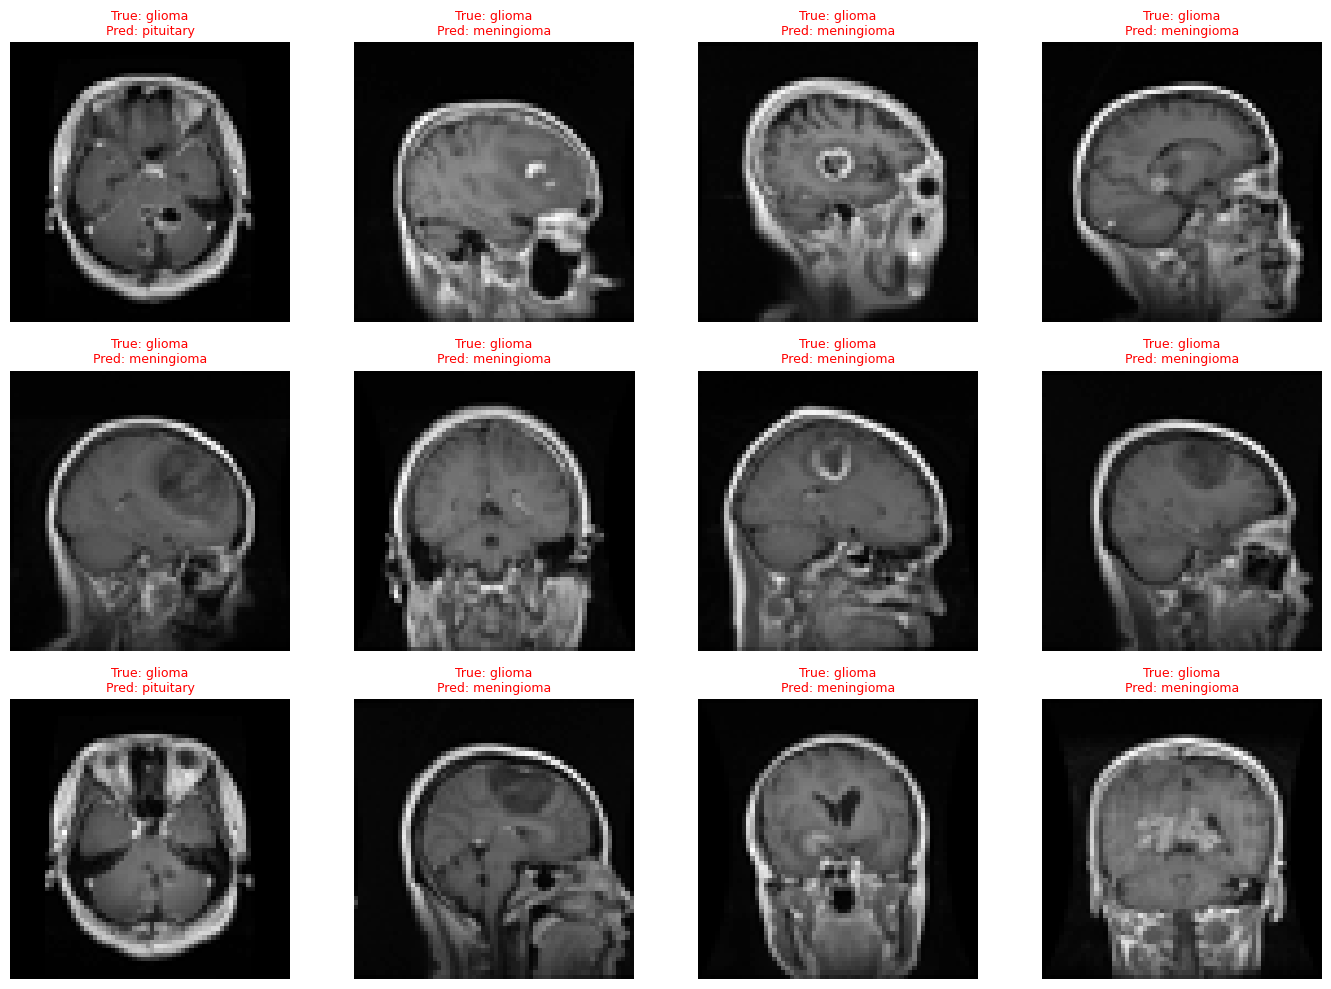

  glioma mistaken as meningioma × 42
  meningioma mistaken as glioma × 21
  meningioma mistaken as no_tumor × 17
  meningioma mistaken as pituitary × 17
  glioma mistaken as pituitary × 5


In [42]:

wrong_idx = np.where(y_pred != y_test)[0]
print(f"Wrong: {len(wrong_idx)} / {len(y_test)}")


for idx in wrong_idx:
    print(f"  [{idx}] True: {CLASS_NAMES[y_test[idx]]}  →  Predicted: {CLASS_NAMES[y_pred[idx]]}")


fig, axes = plt.subplots(3, 4, figsize=(14, 10))
for ax, idx in zip(axes.flatten(), wrong_idx[:12]):
    ax.imshow(X_test[idx].reshape(IMG_SIZE), cmap="gray")
    ax.set_title(f"True: {CLASS_NAMES[y_test[idx]]}\nPred: {CLASS_NAMES[y_pred[idx]]}", color="red", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.savefig("wrong_predictions.png", dpi=150)
plt.show()


from collections import Counter
wrong_true = [CLASS_NAMES[y_test[i]] for i in wrong_idx]
wrong_pred = [CLASS_NAMES[y_pred[i]] for i in wrong_idx]
for (t, p), c in Counter(zip(wrong_true, wrong_pred)).most_common(5):
    print(f"  {t} mistaken as {p} × {c}")

In [43]:
def predict(image_path):
    img  = Image.open(image_path).convert("L").resize(IMG_SIZE)
    flat = np.array(img).flatten() / 255.0
    pred = model.predict([flat])[0]
    print(f"Prediction: {CLASS_NAMES[pred]}")

In [44]:
predict('/kaggle/input/datasets/briscdataset/brisc2025/brisc2025/classification_task/test/glioma/brisc2025_test_00008_gl_ax_t1.jpg')

Prediction: glioma


In [48]:
def load_data_with_paths(split):
    images, labels, paths = [], [], []
    for label, class_name in enumerate(CLASS_NAMES):
        folder = os.path.join(DATA_DIR, split, class_name)
        for filename in os.listdir(folder):
            if filename.endswith((".jpg", ".png")):
                img_path = os.path.join(folder, filename)
                img = Image.open(img_path).convert("L").resize(IMG_SIZE)
                flat = np.array(img).flatten() / 255.0
                images.append(flat)
                labels.append(label)
                paths.append(img_path)
    return np.array(images), np.array(labels), paths

In [49]:
X_test, y_test, test_paths = load_data_with_paths("test")

In [50]:
model =  SVC(kernel = 'rbf', C=1.0,gamma ='scale')

In [51]:
model.fit(X_train, y_train)

SVC()

In [52]:
y_pred = model.predict(X_test)
wrong_indices = np.where(y_pred != y_test)[0]

print("Misclassified images:")
for idx in wrong_indices:
    true_label = CLASS_NAMES[y_test[idx]]
    pred_label = CLASS_NAMES[y_pred[idx]]
    img_path = test_paths[idx]
    print(f"Index {idx}: {true_label} → {pred_label} | {img_path}")

Misclassified images:
Index 2: glioma → pituitary | /kaggle/input/datasets/briscdataset/brisc2025/brisc2025/classification_task/test/glioma/brisc2025_test_00061_gl_ax_t1.jpg
Index 5: glioma → meningioma | /kaggle/input/datasets/briscdataset/brisc2025/brisc2025/classification_task/test/glioma/brisc2025_test_00228_gl_sa_t1.jpg
Index 6: glioma → meningioma | /kaggle/input/datasets/briscdataset/brisc2025/brisc2025/classification_task/test/glioma/brisc2025_test_00226_gl_sa_t1.jpg
Index 9: glioma → meningioma | /kaggle/input/datasets/briscdataset/brisc2025/brisc2025/classification_task/test/glioma/brisc2025_test_00225_gl_sa_t1.jpg
Index 18: glioma → meningioma | /kaggle/input/datasets/briscdataset/brisc2025/brisc2025/classification_task/test/glioma/brisc2025_test_00252_gl_sa_t1.jpg
Index 26: glioma → meningioma | /kaggle/input/datasets/briscdataset/brisc2025/brisc2025/classification_task/test/glioma/brisc2025_test_00096_gl_co_t1.jpg
Index 43: glioma → meningioma | /kaggle/input/datasets/bris